# Quarterly progress of listed Indonesian banks

> **Forward-looking research dashboard, not a buy list.** Shareholders earn future returns, not past returns. This notebook therefore asks whether operating momentum is strengthening, stable, or weakening—and whether the current share price already reflects that outlook.

**Data cut:** retrieved 25 September 2026. The latest fully completed quarter is **Q2 2026**; Q3 2026 is still in progress and must not be treated as reported. Prices run through **24 September 2026**.

The study universe is the 15 largest metadata-covered Indonesian companies classified by Yahoo as `Banks - Regional`, ranked by market capitalisation on 22 September 2026. Quarterly accounting data and prices are a comparison layer from Yahoo/yfinance. Official OJK/IDX filings and issuer presentations are the source of truth before any decision.

## 1. The analytical idea

Your reasoning is correct in the important sense: a strong historical chart does **not** create future earnings. A share can decline despite excellent past results if earnings weaken, risks rise, or its starting valuation was too expensive. Conversely, a weak historical chart can recover if operating results inflect upward and the market had priced in worse outcomes.

The useful chain is:

```text
Macro/funding conditions
  -> deposits, funding cost and credit demand
  -> loan growth, margins, fees and expenses
  -> asset quality and provisions
  -> quarterly profit and capital generation
  -> sustainable future ROE and dividends
  -> fair valuation versus current market price
```

Continuation of a long price rise is weak evidence by itself. It may indicate a durable franchise, but it can also mean the valuation is already demanding. Quarterly fundamental confirmation is more useful than extrapolating the chart.

## 2. What should be monitored every quarter

| Layer | Core questions | Preferred evidence |
|---|---|---|
| Growth | Are loans, deposits, CASA and fees growing? Is growth broad or concentrated? | Issuer quarterly presentation and OJK filing |
| Margin | Are loan yields and funding costs improving? Is NIM resilient? | NIM, cost of funds, loan yield, CASA |
| Credit | Are NPL, Loan at Risk, Stage 2, restructurings and cost of credit moving together? | Full risk tables—not NPL alone |
| Efficiency | Is revenue growing faster than operating cost? | Cost-to-income, BOPO, digital transaction economics |
| Profit | Is profit growth driven by core NII/fees or by recoveries and treasury gains? | Standalone-quarter and YTD bridge |
| Capital/liquidity | Can growth and dividends be funded safely? | CET1/Tier 1, CAR, LDR/FDR, LCR, NSFR |
| Valuation | How much improvement is already priced in? | P/B, P/E, dividend yield versus sustainable ROE |
| Market confirmation | Did price react before or after the filing? | Adjusted price, volume and event dates |

For cumulative filings, calculate a standalone quarter as `current YTD − previous-quarter YTD`. Never compare six-month profit directly with a three-month profit.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
plt.style.use('seaborn-v0_8-whitegrid')

# Objective: resolve ignored market-data artifacts from the repository or notebook directory.
def locate_private(name):
    candidates = [Path('private/market_data/yahoo') / name,
                  Path('../../private/market_data/yahoo') / name]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(f'Could not find {name}; tried {candidates}')

as_of = '2026-09-25'
fund_path = locate_private(f'idx_bank_quarterly_fundamentals_{as_of}.csv')
price_path = locate_private(f'idx_large_bank_prices_{as_of}.csv')
manifest_path = locate_private(f'idx_bank_quarterly_fundamentals_{as_of}.json')

fund = pd.read_csv(fund_path, parse_dates=['period_end'])
prices = pd.read_csv(price_path, parse_dates=['date'])
manifest = json.loads(manifest_path.read_text())
print(f"Fundamental observations: {len(fund):,}")
print(f"Daily price observations: {len(prices):,}")
print(f"Banks requested / covered: {len(manifest['symbols'])} / {len(manifest['coverage'])}")
print(f"Latest market date: {prices['date'].max().date()}")
print(f"Provider errors: {manifest['errors'] or 'none'}")

Matplotlib is building the font cache; this may take a moment.


Fundamental observations: 6,006
Daily price observations: 11,459
Banks requested / covered: 15 / 15
Latest market date: 2026-09-24
Provider errors: none


## 3. Coverage audit

Missing quarters are left missing. They are not interpolated, forward-filled, or interpreted as zero. Yahoo often exposes only five recent quarterly columns and can omit Q3 for some issuers; this is why an official-filing archive is the recommended next data layer.

In [2]:
coverage = (fund.groupby('ticker')['period_end']
            .agg(first_period='min', last_period='max', reported_periods='nunique')
            .sort_values(['last_period', 'reported_periods'], ascending=[False, False]))
period_grid = (fund[['ticker', 'period_end']].drop_duplicates()
               .assign(present='yes')
               .pivot(index='ticker', columns='period_end', values='present')
               .fillna('—'))
display(coverage)
display(period_grid)

,first_period,last_period,reported_periods
ticker,,,
BBHI,2024-12-31,2026-06-30,7
BBNI,2024-12-31,2026-06-30,7
BBRI,2024-12-31,2026-06-30,7
BDMN,2024-12-31,2026-06-30,7
BMRI,2024-12-31,2026-06-30,7
BBCA,2024-12-31,2026-06-30,6
BINA,2024-12-31,2026-06-30,6
BNGA,2025-03-31,2026-06-30,6
BNLI,2024-12-31,2026-06-30,6


period_end,2024-12-31,2025-03-31,2025-06-30,2025-09-30,2025-12-31,2026-03-31,2026-06-30
ticker,,,,,,,
BBCA,yes,yes,yes,—,yes,yes,yes
BBHI,yes,yes,yes,yes,yes,yes,yes
BBNI,yes,yes,yes,yes,yes,yes,yes
BBRI,yes,yes,yes,yes,yes,yes,yes
BDMN,yes,yes,yes,yes,yes,yes,yes
BINA,yes,yes,yes,—,yes,yes,yes
BMRI,yes,yes,yes,yes,yes,yes,yes
BNGA,—,yes,yes,yes,yes,yes,yes
BNLI,yes,yes,yes,—,yes,yes,yes


## 4. Comparable accounting panel

The panel uses provider-standardised fields that exist for most banks:

- Net income, net interest income, total revenue and operating expense are quarterly flows.
- Net loans, equity and assets are quarter-end balances.
- YoY is preferred because banking has seasonality and Q4 adjustments.
- Annualised quarterly ROE is only a momentum indicator (`4 × quarterly profit / equity`), not a forecast of full-year ROE.
- `Operating expense / revenue` here is a rough provider-derived efficiency proxy, **not** the issuer's official BOPO or cost-to-income ratio.

In [3]:
metrics = ['Net Income', 'Net Interest Income', 'Total Revenue', 'Operating Expense',
           'Net Loan', 'Stockholders Equity', 'Total Assets']
panel = (fund[fund['metric'].isin(metrics)]
         .pivot_table(index=['ticker', 'period_end'], columns='metric', values='value', aggfunc='first')
         .reset_index().sort_values(['ticker', 'period_end']))

# Objective: add prior-year values only when the exact comparable quarter exists.
def add_yoy(frame, metric):
    prior = frame[['ticker', 'period_end', metric]].copy()
    prior['period_end'] = prior['period_end'] + pd.DateOffset(years=1)
    prior = prior.rename(columns={metric: f'{metric}_prior_year'})
    frame = frame.merge(prior, on=['ticker', 'period_end'], how='left')
    frame[f'{metric}_yoy'] = frame[metric] / frame[f'{metric}_prior_year'] - 1
    return frame

for metric in metrics:
    panel = add_yoy(panel, metric)

panel['annualised_quarterly_roe'] = 4 * panel['Net Income'] / panel['Stockholders Equity']
panel['expense_to_revenue_proxy'] = panel['Operating Expense'] / panel['Total Revenue']
panel['equity_to_assets'] = panel['Stockholders Equity'] / panel['Total Assets']
panel.shape

(79, 26)

## 5. Latest reported-quarter scoreboard

In [4]:
latest = (panel.dropna(subset=['Net Income'])
          .sort_values('period_end').groupby('ticker', as_index=False).tail(1).copy())
score_cols = ['ticker', 'period_end', 'Net Income_yoy', 'Net Interest Income_yoy',
              'Net Loan_yoy', 'annualised_quarterly_roe',
              'expense_to_revenue_proxy', 'equity_to_assets']
score = latest[score_cols].sort_values('Net Income_yoy', ascending=False)
formats = {c: '{:.1%}' for c in score_cols[2:]}
display(score.style.format(formats).format({'period_end': lambda x: x.date().isoformat()}))

metric,ticker,period_end,Net Income_yoy,Net Interest Income_yoy,Net Loan_yoy,annualised_quarterly_roe,expense_to_revenue_proxy,equity_to_assets
26,BDMN,2026-06-30,0.433349,0.480777,0.183824,0.092544,0.562996,0.180281
37,BMRI,2026-06-30,0.334911,0.020469,-0.006385,0.211223,0.378256,0.112596
21,BBRI,2026-06-30,0.219720,0.076951,0.169864,0.191011,0.413913,0.136850
31,BINA,2026-06-30,0.164150,0.120604,0.248754,0.016193,0.897580,0.086257
9,BBHI,2026-06-30,0.131665,0.104896,0.273472,0.070630,0.425435,0.471394
15,BBNI,2026-06-30,0.080938,0.162979,0.254851,0.124374,0.515000,0.112158
73,NISP,2026-06-30,0.074549,-0.126051,0.120837,0.123512,0.455515,0.134670
53,BRIS,2026-06-30,0.050031,nan,0.150361,0.153259,0.554222,0.109881
78,PNBN,2026-06-30,0.024650,0.057437,-0.061891,0.049866,0.583589,0.232595
42,BNGA,2026-06-30,0.012860,0.008692,0.083978,0.119132,0.449332,0.146900


### How to read the scoreboard

- **BDMN** shows the strongest reported YoY profit and NII acceleration in this provider panel, accompanied by high loan growth. This is an improving-momentum signal, not proof that the stock remains cheap after its large 2026 rise.
- **BMRI and BBRI** combine high annualised quarterly ROE with strong YoY profit growth in the downloaded panel. BMRI's flat/negative net-loan comparison and modest NII growth mean the profit bridge must be checked in its official presentation; one should not assume all growth is recurring core growth.
- **BBNI** shows strong reported NII and loan expansion but lower ROE than the two larger state banks. The official 1H26 release independently reports NII growth of 14.2%, net profit of about Rp10.8tn, gross NPL 1.93%, and ROE 13.4%.
- **BBCA** remains the highest-quality-looking large-bank franchise in this limited panel by ROE and efficiency proxy, but its Q2 YoY profit and NII were approximately flat. Quality and momentum are different questions; valuation determines whether quality is already overpaid.
- **MEGA, BSIM, BTPN and BNLI** show weakening latest profit comparisons or low profitability in the available data. Each needs an issuer-specific explanation before any conclusion: provisions, treasury gains/losses, operating investments, merger effects, and provider mapping can all matter.
- **BINA and BBHI** show rapid loan expansion but much lower profitability than the established leaders. Fast balance-sheet growth without mature credit vintages is a risk signal as well as a growth signal.

These are screening interpretations—not forecasts or recommendations.

## 6. Quarter-by-quarter net profit trajectory

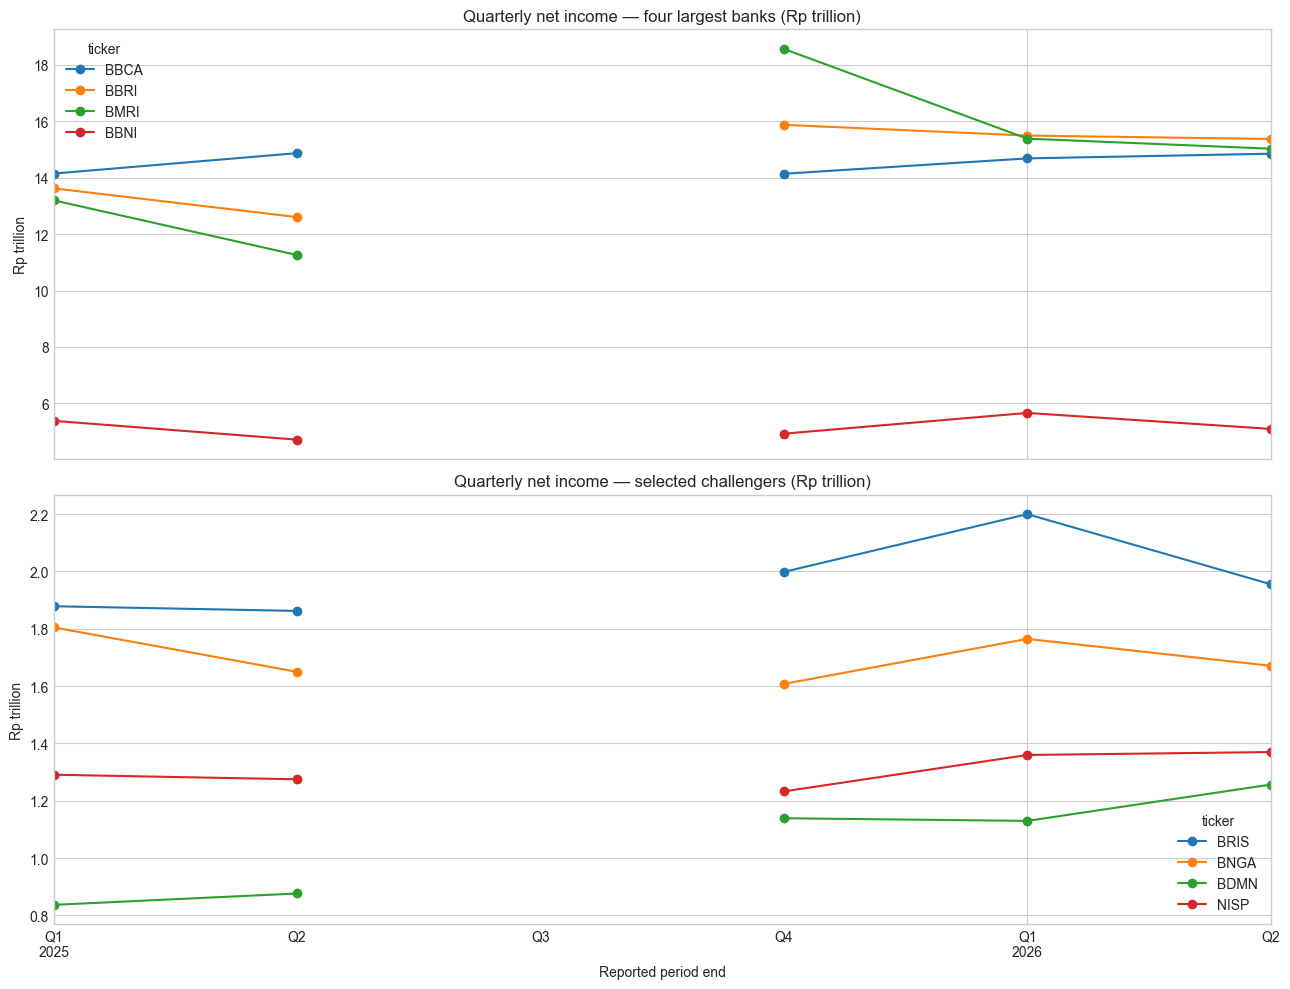

In [5]:
profit = panel.pivot(index='period_end', columns='ticker', values='Net Income') / 1e12
leaders = ['BBCA', 'BBRI', 'BMRI', 'BBNI', 'BRIS', 'BNGA', 'BDMN', 'NISP']
fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=True)
profit[[c for c in leaders[:4] if c in profit]].plot(marker='o', ax=axes[0])
axes[0].set_title('Quarterly net income — four largest banks (Rp trillion)')
profit[[c for c in leaders[4:] if c in profit]].plot(marker='o', ax=axes[1])
axes[1].set_title('Quarterly net income — selected challengers (Rp trillion)')
for ax in axes:
    ax.set_ylabel('Rp trillion'); ax.set_xlabel('Reported period end')
plt.tight_layout(); plt.show()

The lines are not a mechanical ranking. Scale differs substantially, and one quarterly profit can be distorted by provisions, recoveries, securities gains, tax, or consolidation. The useful question is whether the direction agrees with loans, NII, asset quality, and capital—not whether one line is visually highest.

## 7. Loan growth versus profitability

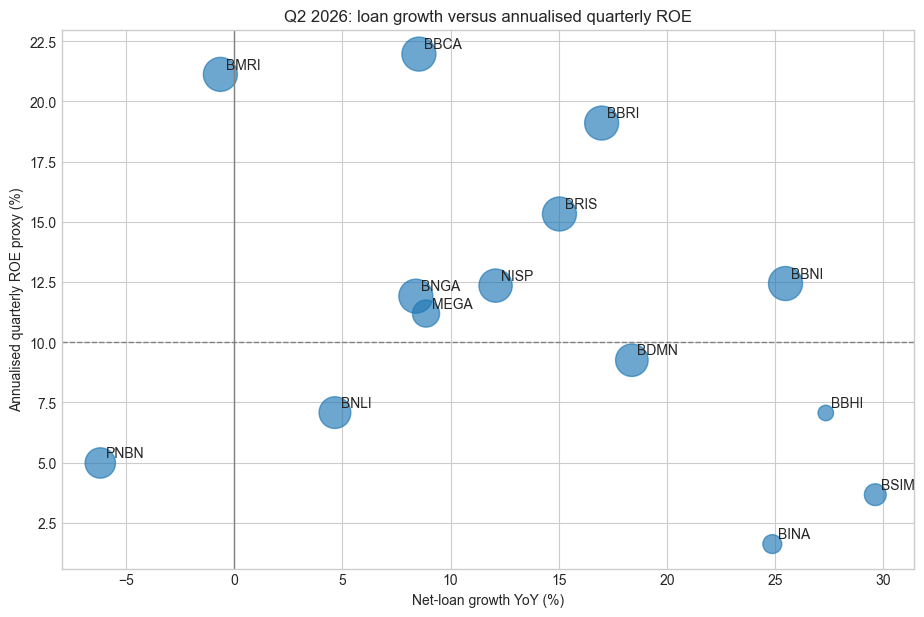

In [6]:
q2 = panel[panel['period_end'].eq(pd.Timestamp('2026-06-30'))].copy()
fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(q2['Net Loan_yoy'] * 100, q2['annualised_quarterly_roe'] * 100,
           s=np.sqrt(q2['Total Assets'] / 1e9).clip(20, 600), alpha=.65)
for _, row in q2.iterrows():
    ax.annotate(row['ticker'], (row['Net Loan_yoy'] * 100,
                                row['annualised_quarterly_roe'] * 100),
                xytext=(4, 4), textcoords='offset points')
ax.axvline(0, color='grey', lw=1); ax.axhline(10, color='grey', lw=1, ls='--')
ax.set(title='Q2 2026: loan growth versus annualised quarterly ROE',
       xlabel='Net-loan growth YoY (%)', ylabel='Annualised quarterly ROE proxy (%)')
plt.show()

A desirable quadrant is positive, controlled growth with a sustainable return above the bank's cost of equity. But very high loan growth can temporarily make credit metrics look better because new loans have not seasoned. That is why the next official-data extension must add Stage 2, LaR, NPL, cost of credit, and coverage by quarter.

## 8. Price response is not the same as fundamental progress

In [7]:
# Objective: calculate returns from the first available close on/after each boundary.
def boundary_return(group, start):
    group = group.sort_values('date')
    eligible = group[group['date'].ge(pd.Timestamp(start))]
    return np.nan if eligible.empty else group.iloc[-1]['adj_close'] / eligible.iloc[0]['adj_close'] - 1

price_summary = []
for ticker, group in prices.groupby('ticker'):
    price_summary.append({
        'ticker': ticker,
        'latest_date': group['date'].max(),
        'latest_adjusted_close': group.sort_values('date').iloc[-1]['adj_close'],
        '2026_ytd_return': boundary_return(group, '2026-01-01'),
        'return_since_q2_end': boundary_return(group, '2026-06-30'),
    })
price_summary = pd.DataFrame(price_summary)
combined = score.merge(price_summary, on='ticker', how='left')
display(combined[['ticker', 'period_end', 'Net Income_yoy', 'Net Loan_yoy',
                  'annualised_quarterly_roe', '2026_ytd_return', 'return_since_q2_end']]
        .sort_values('2026_ytd_return', ascending=False)
        .style.format({c: '{:.1%}' for c in ['Net Income_yoy', 'Net Loan_yoy',
                                             'annualised_quarterly_roe', '2026_ytd_return',
                                             'return_since_q2_end']}))

,ticker,period_end,Net Income_yoy,Net Loan_yoy,annualised_quarterly_roe,2026_ytd_return,return_since_q2_end
0,BDMN,2026-06-30 00:00:00,43.3%,18.4%,9.3%,88.9%,18.1%
14,MEGA,2026-06-30 00:00:00,-24.5%,8.9%,11.2%,22.4%,-1.0%
13,BSIM,2026-06-30 00:00:00,-18.3%,29.6%,3.7%,11.4%,40.0%
12,BTPN,2026-03-31 00:00:00,-10.6%,1.1%,3.8%,9.0%,10.0%
9,BNGA,2026-06-30 00:00:00,1.3%,8.4%,11.9%,7.1%,11.3%
6,NISP,2026-06-30 00:00:00,7.5%,12.1%,12.4%,-6.3%,6.8%
2,BBRI,2026-06-30 00:00:00,22.0%,17.0%,19.1%,-8.2%,15.0%
1,BMRI,2026-06-30 00:00:00,33.5%,-0.6%,21.1%,-9.6%,7.3%
5,BBNI,2026-06-30 00:00:00,8.1%,25.5%,12.4%,-10.2%,11.4%
3,BINA,2026-06-30 00:00:00,16.4%,24.9%,1.6%,-10.7%,-8.9%


The divergence is informative:

- **BDMN** had both fundamental acceleration and a very strong 2026 price move. The next question is valuation: the market may already have capitalised much of the improvement.
- **BBCA, BBRI, BMRI and BBNI** were negative year-to-date in this cut even where profit or quality remained strong. That can reflect valuation compression, macro/foreign-flow risk, or expectations—not necessarily a collapsing franchise.
- **BSIM** rose despite weak latest profit/NII comparisons in the provider panel; **MEGA** was positive year-to-date despite a weak Q2 profit comparison. Such mismatches demand event, liquidity, valuation and disclosure review rather than momentum extrapolation.
- The broad `^JKSE` benchmark was also sharply negative year-to-date in this downloaded series, so absolute bank returns should be separated from market-wide repricing.

This is exactly why neither past price alone nor one earnings-growth number is sufficient.

## 9. Current sector backdrop

The most recent official system snapshot used in the companion market notebook remains July 2026:

| Indicator | Latest cited level | Directional implication |
|---|---:|---|
| Bank loans | Rp9,135tn; +13.58% YoY | Strong system growth; investigate underwriting and funding discipline |
| Deposits | Rp10,336tn; +11.21% YoY | Loans outgrew deposits, increasing the importance of funding price/mix |
| Gross / net NPL | 2.10% / 0.81% | Recognised system stress remained contained |
| Loan at Risk | 8.39% | Broader risk pool is much larger than NPL and should not be ignored |
| ROA | 2.45% | Aggregate profitability remained healthy |
| CAR | 23.84% | Strong system capital, though individual banks differ |
| BI-Rate, 23 Sep 2026 | 5.75% | Funding, loan repricing and valuation remain rate-sensitive |

Sources: [OJK August 2026 sector update](https://iru.ojk.go.id/iru/WebSite/ArticleList/View/1060_Press_Release_August_2026_of_The_Board_of_Commissioners%E2%80%99_Meeting_Financial_Services_Sector_Performance_And_Intermediation_Remain_Solid,_Supporting_Accelerated_Economic_Growth) and [Bank Indonesia September 2026 decision](https://www.bi.go.id/id/publikasi/ruang-media/news-release/Pages/sp_2819326.aspx).

## 10. Source-of-truth links for quarterly work

Yahoo makes the comparison reproducible, but investor-relations materials carry the bank-specific ratios and management explanations required for real analysis:

- [BCA quarterly and monthly financial statements](https://www.bca.co.id/id/tentang-bca/Hubungan-Investor/laporan-presentasi/Laporan-Keuangan)
- [BRI 2026 quarterly presentations](https://www.ir-bri.com/slides.html/year/2026)
- [Bank Mandiri quarterly presentations](https://www.bankmandiri.co.id/en/web/ir/corporate-presentations)
- [BNI quarterly financial statements](https://www.bni.co.id/id-id/investor/laporan-keuangan) and [events/presentations](https://www.bni.co.id/en-us/investors/events-presentation)
- [CIMB Niaga financial highlights](https://investor.cimbniaga.co.id/fn_highlights.html)
- [OCBC Indonesia financial information](https://www.ocbc.id/en/tentang-ocbc/hubungan-investor/informasi-keuangan)
- [BSI investor relations](https://ir.bankbsi.co.id/)

The official archive should ultimately store, for each bank-quarter: release date, period end, scope (bank-only/consolidated), units, original URL/file hash, whether values are cumulative or standalone, and restatement status.

## 11. Forward-looking interpretation framework

For each bank, assign evidence—not a simplistic score—to four states:

| State | Evidence pattern | Interpretation |
|---|---|---|
| Improving | Core income accelerates; funding and asset quality stable/improve; capital adequate | Candidate for deeper valuation work |
| Healthy but slowing | Strong ROE/quality, but growth or margins decelerate | Good franchise may still disappoint if valuation assumes acceleration |
| Growth with rising risk | Loans grow quickly while Stage 2/LaR, funding cost or dilution worsens | Future loss risk may be hidden by current growth |
| Turnaround/speculative | Profit improves from a weak base but returns remain below cost of equity | Upside depends on execution; valuation and dilution are decisive |

Then build scenarios rather than a single forecast:

```text
Bear: weaker credit demand + margin compression + higher cost of credit
Base: management guidance partly achieved + normalised provisions
Bull: deposit franchise improves + quality growth + operating leverage
```

Estimate sustainable ROE, book-value growth and dividends under each scenario. Compare those results with current P/B and P/E. A bank is not attractive merely because its profits are rising; it must improve more than the market price already expects.

## 12. What the present evidence says—and does not say

**Supported by the current cut:**

- Indonesia's banking system remained profitable, growing, liquid and well capitalised in aggregate through July 2026.
- Among the large-bank comparison set, quarterly momentum was heterogeneous: BDMN, BMRI, BBRI and BBNI screened positively on profit growth; BBCA screened strongly on profitability/efficiency but with flat Q2 growth; several smaller or mid-sized banks displayed either weak profitability or weak latest profit momentum.
- Market returns diverged materially from reported accounting momentum, demonstrating that expectations and valuation matter.

**Not supported yet:**

- A reliable one-number ranking or buy/sell recommendation.
- A claim that Yahoo's standardised accounts match every official filing field.
- A full credit-quality comparison, because consistent quarterly NPL, LaR, Stage 2, cost-of-credit, coverage, CASA, NIM, CAR and liquidity fields have not yet been archived for all 15 banks.
- A forecast based on five observations. At least 12–20 official quarters are preferable for cycle-aware trend analysis.

The right next engineering step is an official-filing ingestion table. This notebook is the working comparison framework and current screening layer, not the final valuation model.

## 13. Reproduce and refresh

From the repository root:

```bash
uv run --with yfinance --with pandas python scripts/fetch_yahoo_bank_quarterly.py \
  --as-of 2026-09-25 --metadata-date 2026-09-22 --top 15
python3 scripts/build_bank_quarterly_progress_notebook.py
```

The raw CSV and manifest files remain under ignored `private/market_data/yahoo/`. Refresh only after a reporting season is substantially complete, preserve the old vintage, and never overwrite historical snapshots.